Starting Boids Simulation...
  N=150 | World=100.0x100.0
  Weights: Sep=1.5, Ali=1.0, Coh=1.0
  Close the animation window to exit (or stop the cell in Colab).


/tmp/ipython-input-1778885464.py:196: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, update, frames=None, interval=30, blit=False)


KeyboardInterrupt: 

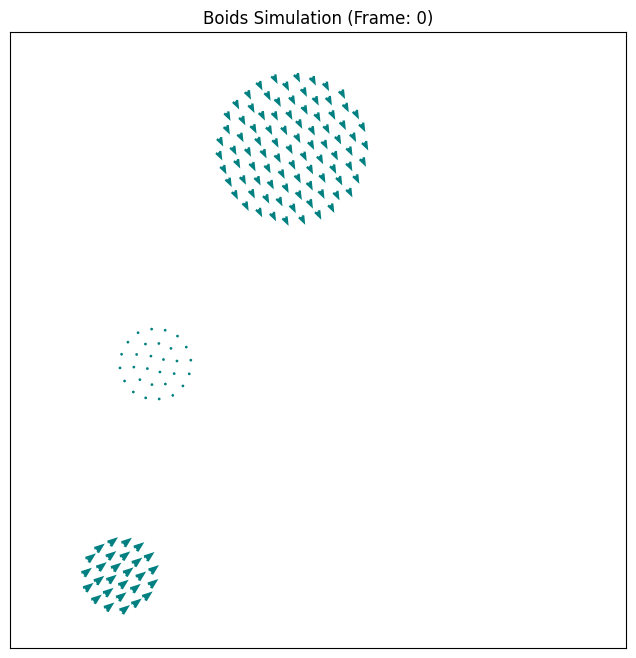

In [2]:
#!/usr/bin/env python3
"""
boids.py

A simple 2D boids (flocking) simulation using numpy and matplotlib.
Implements separation, alignment, and cohesion rules in a toroidal world.

Usage:
    python boids.py
    python boids.py --n-boids 200
"""

import sys
import argparse

# --- 1. Environment & Dependencies ---

try:
    import numpy as np
except ImportError as e:
    print("Error: numpy is required but not installed.")
    print(f"Details: {e}")
    print("Please install it via: pip install numpy")
    sys.exit(1)

try:
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation
except ImportError as e:
    print("Error: matplotlib is required but not installed.")
    print(f"Details: {e}")
    print("Please install it via: pip install matplotlib")
    sys.exit(1)

# For notebook environments, prefer JS HTML animation
plt.rcParams["animation.html"] = "jshtml"

# --- 2. Parameters & Constants ---

# Exposed parameters as requested
N_BOIDS = 150
MAX_SPEED = 2.0
NEIGHBOR_RADIUS = 10.0
SEPARATION_WEIGHT = 1.5
ALIGNMENT_WEIGHT = 1.0
COHESION_WEIGHT = 1.0
DT = 0.5  # Time step
WORLD_SIZE = 100.0  # World dimensions [0, WORLD_SIZE] x [0, WORLD_SIZE]


def init_boids(n, world_size, max_speed):
    """
    Initialize boid positions and velocities with random values.

    Args:
        n (int): Number of boids.
        world_size (float): Size of the square world.
        max_speed (float): Maximum initial speed.

    Returns:
        positions (ndarray): (N, 2) array of positions.
        velocities (ndarray): (N, 2) array of velocities.
    """
    positions = np.random.rand(n, 2) * world_size

    angles = np.random.rand(n) * 2 * np.pi
    velocities = np.stack((np.cos(angles), np.sin(angles)), axis=1) * max_speed

    return positions, velocities


def update_boids(positions, velocities, params):
    """
    Perform one simulation step using vectorized numpy operations.

    Args:
        positions (ndarray): Current positions (N, 2).
        velocities (ndarray): Current velocities (N, 2).
        params (dict): Simulation parameters (weights, radius, etc).

    Returns:
        positions (ndarray): Updated positions.
        velocities (ndarray): Updated velocities.
    """
    n = positions.shape[0]
    world_size = params['world_size']

    # --- 1. Compute Pairwise Differences (Torus Topology) ---
    diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]

    half_world = world_size / 2.0
    diff[diff > half_world] -= world_size
    diff[diff < -half_world] += world_size

    dist_sq = np.sum(diff**2, axis=2)
    dist = np.sqrt(dist_sq)

    neighbor_mask = (dist < params['neighbor_radius']) & (dist > 0)

    neighbor_counts = neighbor_mask.sum(axis=1, keepdims=True)
    neighbor_counts_safe = np.maximum(neighbor_counts, 1)

    # --- 2. Compute Rules ---

    # Separation
    with np.errstate(divide='ignore', invalid='ignore'):
        repulsion = diff / (dist_sq[:, :, np.newaxis] + 1e-8)
    repulsion *= neighbor_mask[:, :, np.newaxis]
    separation_steer = np.sum(repulsion, axis=1) * params['separation_weight']

    # Alignment
    neighbor_vels = velocities[np.newaxis, :, :]
    avg_vel = np.sum(neighbor_vels * neighbor_mask[:, :, np.newaxis], axis=1) / neighbor_counts_safe
    alignment_steer = (avg_vel - velocities) * params['alignment_weight']

    # Optional: no alignment if no neighbors
    no_neighbors = (neighbor_counts == 0).reshape(-1)
    alignment_steer[no_neighbors] = 0.0

    # Cohesion
    neighbor_rel_pos = -diff
    neighbor_rel_pos *= neighbor_mask[:, :, np.newaxis]
    avg_rel_pos = np.sum(neighbor_rel_pos, axis=1) / neighbor_counts_safe
    cohesion_steer = avg_rel_pos * params['cohesion_weight']

    # --- 3. Update State ---
    total_force = separation_steer + alignment_steer + cohesion_steer

    velocities += total_force * params['dt']

    speeds = np.linalg.norm(velocities, axis=1, keepdims=True)
    mask_too_fast = speeds > params['max_speed']
    velocities[mask_too_fast[:, 0]] = (
        velocities[mask_too_fast[:, 0]] / speeds[mask_too_fast[:, 0]]
    ) * params['max_speed']

    positions += velocities * params['dt']
    positions %= world_size

    return positions, velocities


def main():
    """
    Main function to setup arguments, initialize simulation, and run animation.
    """
    parser = argparse.ArgumentParser(description="Simple 2D Boids Simulation")
    parser.add_argument('--n-boids', type=int, default=N_BOIDS,
                        help=f'Number of boids (default: {N_BOIDS})')

    # IMPORTANT: use parse_known_args so Jupyter/Colab extra args don't break it
    args, _ = parser.parse_known_args()

    if args.n_boids <= 0:
        print("Error: --n-boids must be a positive integer.")
        sys.exit(1)

    params = {
        'world_size': WORLD_SIZE,
        'max_speed': MAX_SPEED,
        'neighbor_radius': NEIGHBOR_RADIUS,
        'separation_weight': SEPARATION_WEIGHT,
        'alignment_weight': ALIGNMENT_WEIGHT,
        'cohesion_weight': COHESION_WEIGHT,
        'dt': DT
    }

    print("Starting Boids Simulation...")
    print(f"  N={args.n_boids} | World={WORLD_SIZE}x{WORLD_SIZE}")
    print(f"  Weights: Sep={SEPARATION_WEIGHT}, Ali={ALIGNMENT_WEIGHT}, Coh={COHESION_WEIGHT}")
    print("  Close the animation window to exit (or stop the cell in Colab).")

    positions, velocities = init_boids(args.n_boids, WORLD_SIZE, MAX_SPEED)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, WORLD_SIZE)
    ax.set_ylim(0, WORLD_SIZE)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    quiver = ax.quiver(
        positions[:, 0], positions[:, 1],
        velocities[:, 0], velocities[:, 1],
        pivot='mid', color='teal', scale=40, headwidth=3, headlength=4
    )

    def update(frame):
        nonlocal positions, velocities
        positions, velocities = update_boids(positions, velocities, params)
        quiver.set_offsets(positions)
        quiver.set_UVC(velocities[:, 0], velocities[:, 1])
        ax.set_title(f"Boids Simulation (Frame: {frame})")
        return quiver,

    anim = FuncAnimation(fig, update, frames=None, interval=30, blit=False)

    # Notebook vs script: show appropriately
    try:
        from IPython.display import HTML
        return HTML(anim.to_jshtml())
    except ImportError:
        plt.show()


if __name__ == "__main__":
    main()
